In [1]:
import os
import requests
from requests.auth import HTTPBasicAuth

# --- Configuration ---
USERNAME = "akash2947"
PASSWORD = "Deshpande@01"

# List of URLs you want to download
URLS = [
    "https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0447_CMC_snow_depth_v01/Snow_Depth/Snow_Depth_Daily_Values/GeoTIFF/cmc_sdepth_dly_2020_v01.2.tif"
]

OUTPUT_DIR = "./nsidc_downloads"
os.makedirs(OUTPUT_DIR, exist_ok=True)


class EarthdataAuth(requests.auth.AuthBase):
    """Custom authentication handler for NASA Earthdata redirects."""
    def __init__(self, username, password):
        self.username = username
        self.password = password

    def __call__(self, r):
        r.headers['User-Agent'] = 'Mozilla/5.0'
        return r


def download_file(url, session):
    filename = os.path.join(OUTPUT_DIR, url.split("/")[-1])
    print(f"Downloading: {url} -> {filename}")

    # Initial request
    response = session.get(url, stream=True)

    # Handle Earthdata redirect/authentication
    if response.history and "urs.earthdata.nasa.gov" in response.url:
        response = session.get(
            response.url,
            auth=HTTPBasicAuth(USERNAME, PASSWORD),
            stream=True
        )

    response.raise_for_status()

    with open(filename, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    print(f"Finished: {filename}")


if __name__ == "__main__":
    session = requests.Session()
    session.auth = (USERNAME, PASSWORD)

    for file_url in URLS:
        try:
            download_file(file_url, session)
        except Exception as e:
            print(f"Failed to download {file_url}: {e}")

Downloading: https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0447_CMC_snow_depth_v01/Snow_Depth/Snow_Depth_Daily_Values/GeoTIFF/cmc_sdepth_dly_2020_v01.2.tif -> ./nsidc_downloads\cmc_sdepth_dly_2020_v01.2.tif
Finished: ./nsidc_downloads\cmc_sdepth_dly_2020_v01.2.tif


In [2]:
%pip install rasterio matplotlib numpy

   ---------------------------------------- 0.0/30.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/30.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/30.6 MB ? eta -:--:--
    --------------------------------------- 0.5/30.6 MB 1.5 MB/s eta 0:00:21
   - -------------------------------------- 1.0/30.6 MB 1.8 MB/s eta 0:00:17
   - -------------------------------------- 1.3/30.6 MB 1.9 MB/s eta 0:00:16
   -- ------------------------------------- 1.8/30.6 MB 2.0 MB/s eta 0:00:15
   --- ------------------------------------ 2.6/30.6 MB 2.2 MB/s eta 0:00:13
   ---- ----------------------------------- 3.1/30.6 MB 2.3 MB/s eta 0:00:12
   ----- ---------------------------------- 4.2/30.6 MB 2.6 MB/s eta 0:00:11
   ------ --------------------------------- 5.0/30.6 MB 2.8 MB/s eta 0:00:10
   -------- ------------------------------- 6.3/30.6 MB 3.2 MB/s eta 0:00:08
   --------- ------------------------------ 7.6/30.6 MB 3.5 MB/s eta 0:00:07
   ----------- -----

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..999.9].


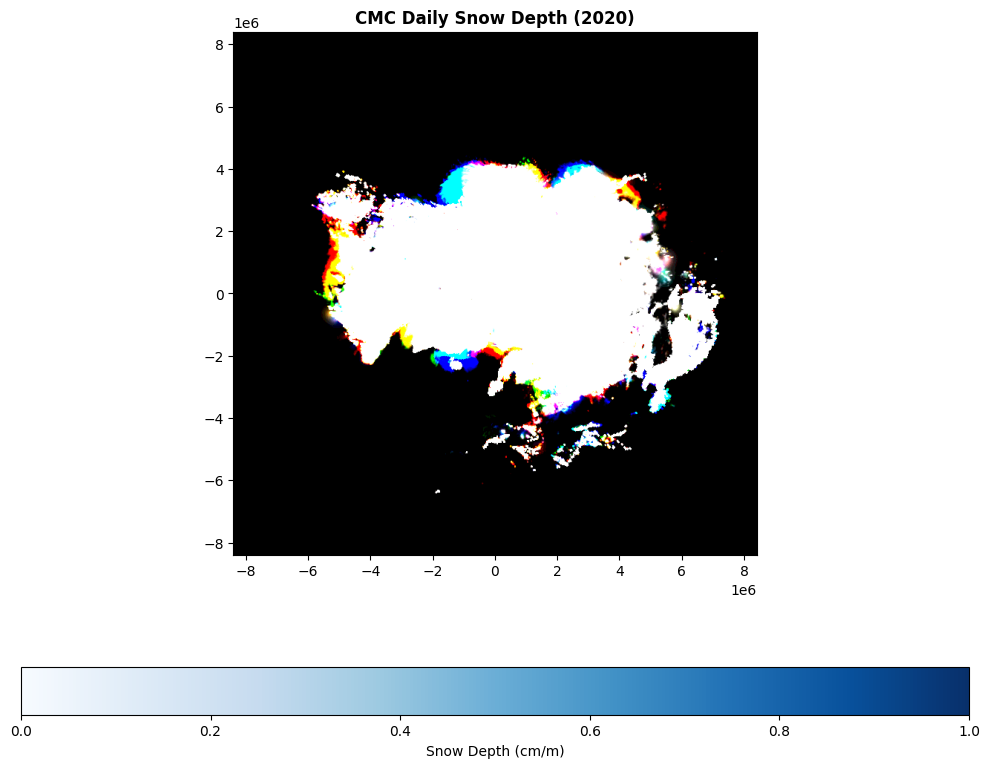

In [3]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

file_path = "./nsidc_downloads/cmc_sdepth_dly_2020_v01.2.tif"

with rasterio.open(file_path) as dataset:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use rasterio's built-in plotting utility to preserve geospatial coordinates
    image = show(dataset, ax=ax, cmap="Blues", title="CMC Daily Snow Depth (2020)")
    
    # Add a colorbar
    fig.colorbar(ax.images[0], ax=ax, orientation="horizontal", label="Snow Depth (cm/m)")
    plt.tight_layout()
    plt.show()

In [ ]:
import rasterio
import numpy as np

# Path to the downloaded .tif file
file_path = "./nsidc_downloads/cmc_sdepth_dly_2020_v01.2.tif"

with rasterio.open(file_path) as dataset:
    # Basic dataset information
    print(f"Bands / Layers count: {dataset.count}")
    print(f"Dimensions (width, height): {dataset.width} x {dataset.height}")
    print(f"Coordinate Reference System (CRS): {dataset.crs}")
    print(f"Bounding box: {dataset.bounds}")
    print(f"NoData value: {dataset.nodata}")

    snow_depth = dataset.read(1)

    # Mask out NoData / fill values if present
    if dataset.nodata is not None:
        snow_depth = np.where(snow_depth == dataset.nodata, np.nan, snow_depth)

    print(f"\nArray shape: {snow_depth.shape}")
    print(f"Min snow depth: {np.nanmin(snow_depth)}")
    print(f"Max snow depth: {np.nanmax(snow_depth)}")
    print(f"Mean snow depth: {np.nanmean(snow_depth):.2f}")

Bands / Layers count: 366
Dimensions (width, height): 706 x 706
Coordinate Reference System (CRS): PROJCS["unnamed",GEOGCS["unnamed ellipse",DATUM["unknown",SPHEROID["unnamed",6371200,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",60],PARAMETER["central_meridian",10],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",SOUTH],AXIS["Northing",SOUTH]]
Bounding box: BoundingBox(left=-8405812.0, bottom=-8405812.0, right=8405812.0, top=8405812.0)
NoData value: -1.7e+308

Array shape: (706, 706)
Min snow depth: 0.0
Max snow depth: 999.9
Mean snow depth: 15.93
